# Bank Customer Churn Prediction
**MSE 446 — Group 3**

---

## Section 1 — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = 'data/raw/Customer-Churn-Records.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')

/var/folders/_m/3cmgszz505gfs0_yh7kmkhp40000gn/T/ipykernel_32064/3741919262.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Shape: (10000, 18)


### 1.1 Dataset Overview

In [2]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000



The dataset contains 10,000 observations and 14 features. It includes a mix of numerical variables (e.g., Age, Balance, CreditScore) and categorical variables (e.g., Geography, Gender, Card Type). 

The target variable is `Exited`, which indicates whether a customer has churned (1) or been retained (0).

### 1.2 Missing Values & Duplicates

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None')

dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')

Missing values per column:
None

Duplicate rows: 0



No missing values or duplicate records were detected in the dataset. This indicates that the data is already clean and does not require imputation or deduplication prior to modeling.

### 1.3 Class Imbalance

Churn distribution:
  Retained (0): 7,962  (79.6%)
  Churned (1): 2,038  (20.4%)


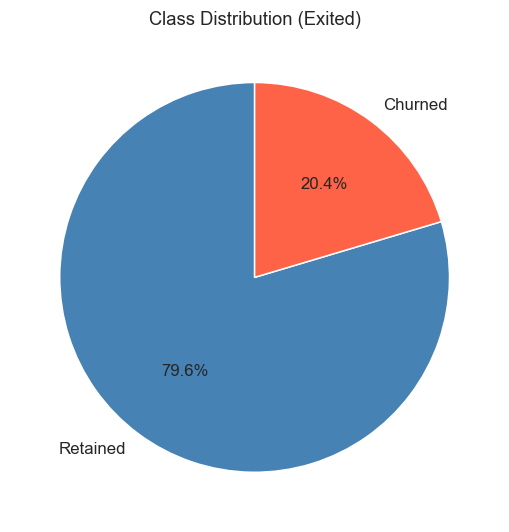

In [6]:
counts = df['Exited'].value_counts()
pcts   = df['Exited'].value_counts(normalize=True) * 100

print('Churn distribution:')
for label, cnt, pct in zip(['Retained (0)', 'Churned (1)'], counts, pcts):
    print(f'  {label}: {cnt:,}  ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['steelblue', 'tomato']
wedges, texts, autotexts = ax.pie(counts, labels=['Retained', 'Churned'], colors=colors, 
                                    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Class Distribution (Exited)', fontsize=12)
plt.tight_layout()
plt.show()


The dataset exhibits a moderate class imbalance, with approximately 20% of customers having churned and 80% retained.

Due to this imbalance, accuracy is not an appropriate standalone evaluation metric, as a model can achieve high accuracy by simply predicting the majority class.

Instead, recall will be prioritized to ensure that churned customers are correctly identified, minimizing false negatives. In addition, the F1-score will be used to balance recall and precision, ensuring that improvements in recall do not come at the cost of excessive false positives.

This aligns with the objective of identifying at-risk customers for retention strategies, where failing to detect a churner is more costly than incorrectly flagging a non-churner.

### 1.4 Key Feature vs Churn Visualizations

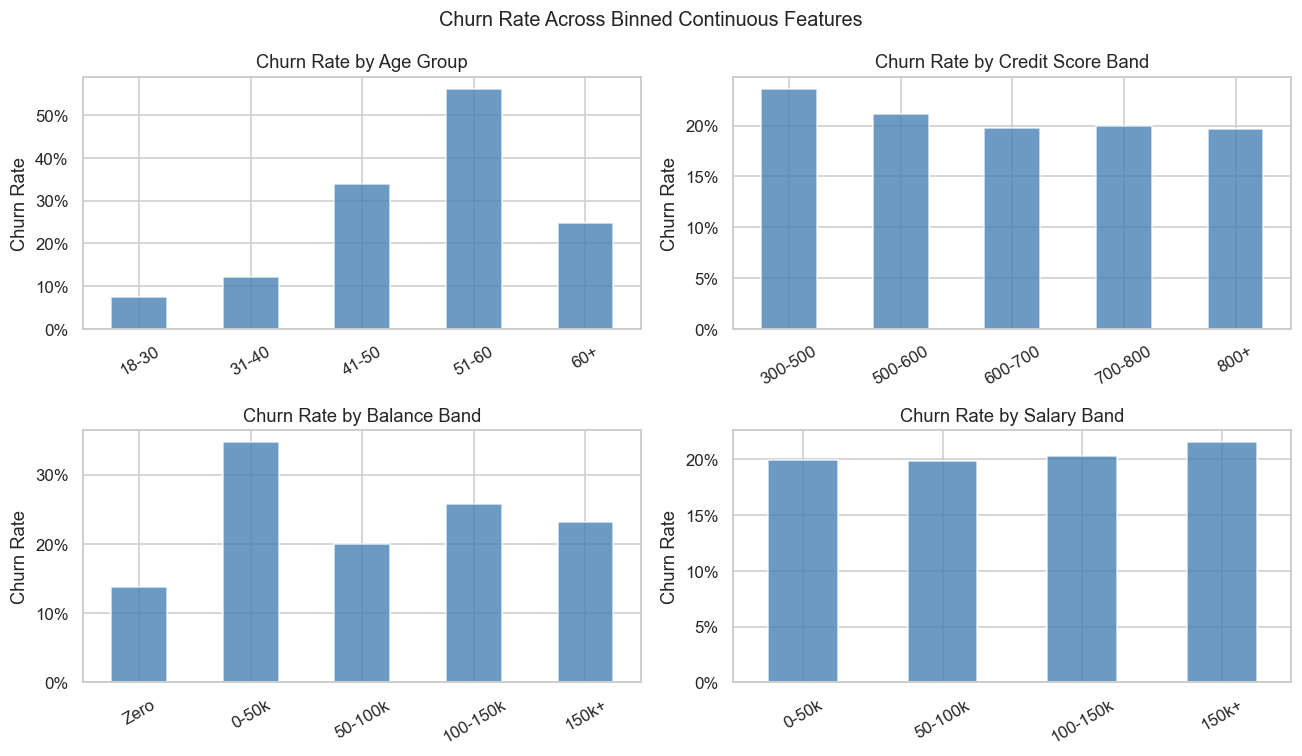

In [7]:
# Bin continuous features, then plot churn rate per bin 
age_churn    = df.groupby(pd.cut(df["Age"],             [18,30,40,50,60,92],        labels=["18-30","31-40","41-50","51-60","60+"]),    observed=True)["Exited"].mean()
credit_churn = df.groupby(pd.cut(df["CreditScore"],     [300,500,600,700,800,851],   labels=["300-500","500-600","600-700","700-800","800+"]), observed=True)["Exited"].mean()
balance_churn= df.groupby(pd.cut(df["Balance"],         [-1,0,50000,100000,150000,300000], labels=["Zero","0-50k","50-100k","100-150k","150k+"]),   observed=True)["Exited"].mean()
salary_churn = df.groupby(pd.cut(df["EstimatedSalary"], [0,50000,100000,150000,200001],    labels=["0-50k","50-100k","100-150k","150k+"]),             observed=True)["Exited"].mean()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 7))

age_churn.plot(kind="bar",    ax=ax1, color="steelblue", alpha=0.8, edgecolor="white")
credit_churn.plot(kind="bar", ax=ax2, color="steelblue", alpha=0.8, edgecolor="white")
balance_churn.plot(kind="bar",ax=ax3, color="steelblue", alpha=0.8, edgecolor="white")
salary_churn.plot(kind="bar", ax=ax4, color="steelblue", alpha=0.8, edgecolor="white")

ax1.set_title("Churn Rate by Age Group")
ax2.set_title("Churn Rate by Credit Score Band")
ax3.set_title("Churn Rate by Balance Band")
ax4.set_title("Churn Rate by Salary Band")

for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel("")
    ax.set_ylabel("Churn Rate")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Churn Rate Across Binned Continuous Features", fontsize=13)
plt.tight_layout()
plt.show()

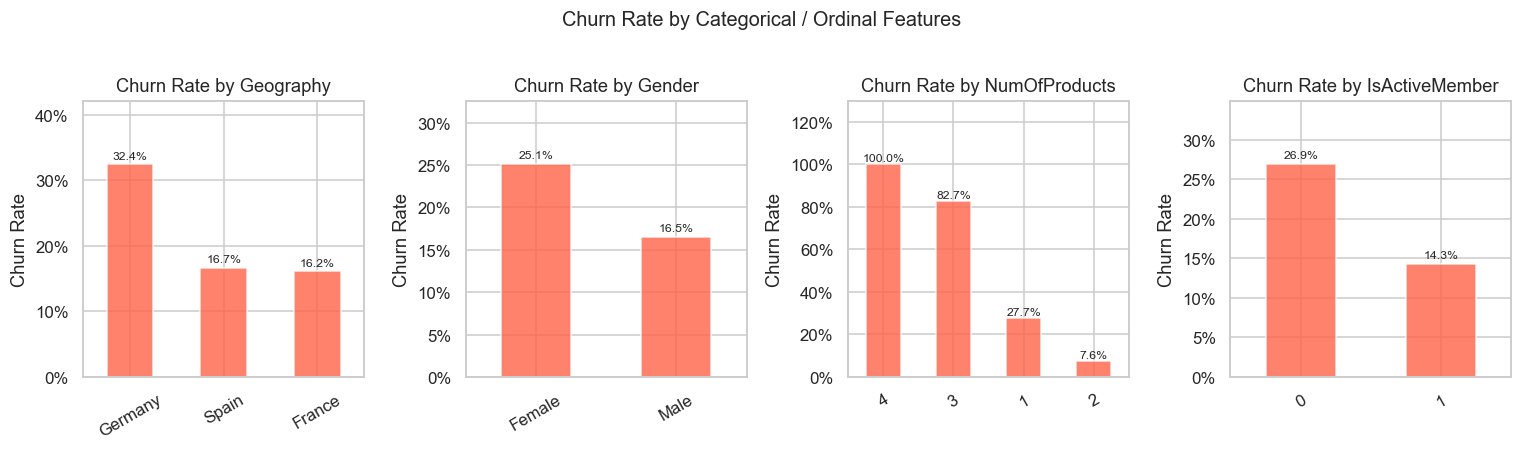

In [8]:
# Categorical / ordinal features: Geography, Gender, NumOfProducts, IsActiveMember
cat_features = ['Geography', 'Gender', 'NumOfProducts', 'IsActiveMember']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, cat_features):
    churn_rate = df.groupby(col)['Exited'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='tomato', alpha=0.8, edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.set_ylim(0, churn_rate.max() * 1.3)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(ax.patches, churn_rate):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Churn Rate by Categorical / Ordinal Features', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Several key patterns emerge from the feature analysis:

- Churn rate increases with age, suggesting that older customers are more likely to leave the bank  
- Customers with non-zero balances tend to churn more frequently than those with zero balances  
- Inactive members exhibit significantly higher churn rates compared to active customers  
- Customers with a higher number of products (3–4) show elevated churn risk  
- Certain geographic segments (e.g., Germany) display notably higher churn rates  

These relationships indicate that both behavioral and demographic factors contribute to customer churn.

### 1.5 Correlation Heatmap

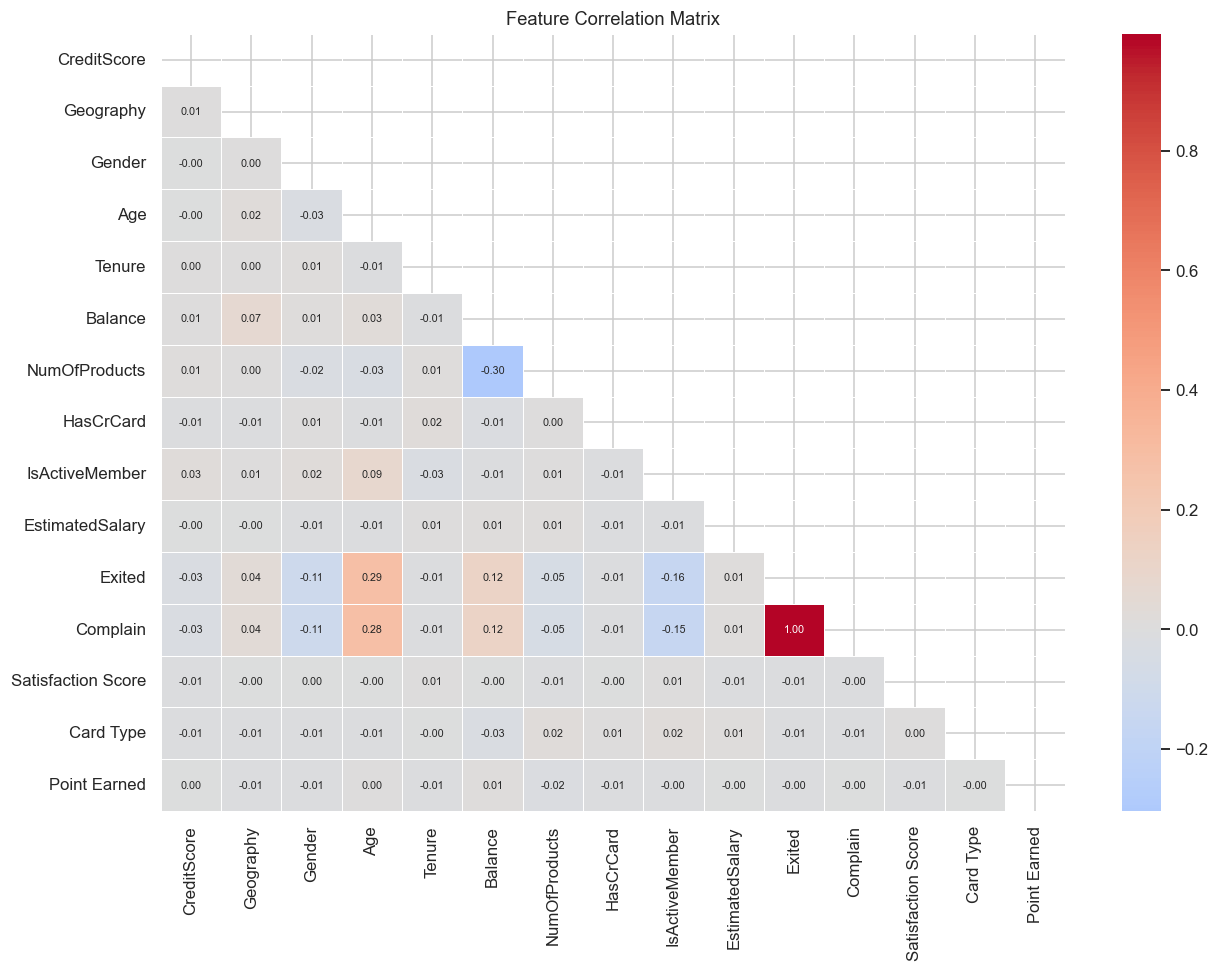

In [9]:
# Encode categoricals minimally for correlation purposes only
df_corr = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
df_corr["Geography"] = df_corr["Geography"].astype("category").cat.codes
df_corr["Gender"]    = df_corr["Gender"].astype("category").cat.codes
df_corr["Card Type"] = df_corr["Card Type"].astype("category").cat.codes

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.show()

The correlation analysis reveals the following:

- **Complain ↔ Exited ≈ 1.0** — this near-perfect correlation indicates that `Complain` is a post-event variable and acts as a proxy for churn. Including it would introduce data leakage, so it must be removed before modeling  
- **Age** shows the strongest legitimate positive correlation with churn among continuous variables  
- **IsActiveMember** has a meaningful negative correlation with churn, indicating that active users are less likely to leave  
- Most other features exhibit weak correlations with each other, which is beneficial for tree-based models as it reduces redundancy and multicollinearity  

Overall, the feature space is well-suited for tree-based methods.

### 1.6 Summary of EDA Insights

| Observation | Detail |
|---|---|
| **Class imbalance** | ~20% churn vs ~80% retained — moderate imbalance; recall is the primary metric |
| **Age** | Churned customers skew older (~45) vs retained (~35); strongest continuous predictor |
| **Balance** | Bimodal in retained (many zero-balance accounts); churned customers tend to carry positive balances |
| **NumOfProducts** | Customers with 3–4 products churn at very high rates |
| **Geography** | Germany churn rate (~32%) roughly double France/Spain (~16%) |
| **IsActiveMember** | Inactive members churn at ~27% vs ~14% for active members |
| **Complain** | Near-perfect correlation with `Exited` — **data leakage**, must be dropped before modeling |
| **Missing / duplicates** | None found — dataset is clean |
| **Identifiers** | `RowNumber`, `CustomerId`, `Surname` carry no predictive signal — will be dropped |

These insights provide a clear understanding of the dataset and will guide subsequent preprocessing and modeling steps. In particular:

- Class imbalance motivates the use of recall as the primary evaluation metric, supported by F1-score to balance precision and recall  
- Key features such as Age, Balance, and Activity Status are expected to be important predictors  
- The `Complain` variable must be removed to prevent data leakage  
- Minimal preprocessing is required due to the absence of missing values and duplicates  

The next step is to clean the dataset by removing non-informative identifiers and eliminating the leakage variable before preparing the data for modeling.

## Section 2 — Cleaning

In [10]:
df_raw = df.copy()  # preserve original for reference
#  drop identifiers, columns with no predictive singal and data leakage columns
df = df.drop(columns=[ "RowNumber", "CustomerId", "Surname", "Complain"])

print(f"Shape after cleaning: {df.shape}")
print(f"Columns remaining: {df.columns.tolist()}")

Shape after cleaning: (10000, 14)
Columns remaining: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Card Type', 'Point Earned']


In [11]:
# Confirm no remaining issues
assert df.isnull().sum().sum() == 0, "Unexpected nulls"
assert df.duplicated().sum() == 0,   "Unexpected duplicates"
print("No missing values or duplicates — dataset is clean.")

No missing values or duplicates — dataset is clean.


## Section 3 — Preprocessing

### 3.1 One-Hot Encoding

In [12]:
# OHE for Geography, Gender, Card Type — drop_first=False to avoid implicit assumptions
df = pd.get_dummies(df, columns=["Geography", "Gender", "Card Type"])
print(f"Shape after OHE: {df.shape}")
print(df.dtypes)

Shape after OHE: (10000, 20)
CreditScore             int64
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Satisfaction Score      int64
Point Earned            int64
Geography_France         bool
Geography_Germany        bool
Geography_Spain          bool
Gender_Female            bool
Gender_Male              bool
Card Type_DIAMOND        bool
Card Type_GOLD           bool
Card Type_PLATINUM       bool
Card Type_SILVER         bool
dtype: object


### 3.2 Train / Test Split

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}  |  Test churn rate: {y_test.mean():.3f}")

Train: (8000, 19)  |  Test: (2000, 19)
Train churn rate: 0.204  |  Test churn rate: 0.204


### 3.3 Feature Scaling (Logistic Regression only)

StandardScaler is applied **only for logistic regression**, which is sensitive to feature magnitude. Tree-based models (decision tree, bagging, random forest) split on thresholds and are invariant to monotonic rescaling — scaling neither helps nor hurts them, so we skip it to keep the pipeline simple.

The scaler is **fit on the training set only** and applied to both train and test to prevent data leakage.

In [14]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ["CreditScore", "Age", "Tenure", "Balance",
                   "NumOfProducts", "EstimatedSalary", "Satisfaction Score", "Point Earned"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print("Scaling applied to:", continuous_cols)
print(f"X_train_scaled mean (CreditScore): {X_train_scaled['CreditScore'].mean():.4f}")
print(f"X_train_scaled std  (CreditScore): {X_train_scaled['CreditScore'].std():.4f}")

Scaling applied to: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']
X_train_scaled mean (CreditScore): 0.0000
X_train_scaled std  (CreditScore): 1.0001


## Section 4 — Modeling

### 4.1 Logistic Regression (Baseline)

Logistic regression is used as the baseline classifier. Since the dataset is moderately imbalanced and failing to identify a churner is more costly than incorrectly flagging a retained customer, the model is tuned using recall as the primary cross-validation metric. F1-score and ROC-AUC are also reported to provide a more balanced evaluation.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Default logistic regression baseline
lr_model = LogisticRegression(
    class_weight='balanced',  # handle class imbalance
    max_iter=1000,           # ensure convergence
    random_state=42         # reproducibility
)

lr_model.fit(X_train_scaled, y_train)

# Predictions and probabilities

#returns class labels (0 or 1)
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred  = lr_model.predict(X_test_scaled)

#returns probability of the positive class (churn) for each instance in the training/test set
lr_train_prob = lr_model.predict_proba(X_train_scaled)[:, 1] 
lr_test_prob  = lr_model.predict_proba(X_test_scaled)[:, 1]

# Baseline performance
print("Default Logistic Regression Performance")
print(f"Train Recall:  {recall_score(y_train, lr_train_pred):.3f}")
print(f"Train F1:      {f1_score(y_train, lr_train_pred):.3f}")
print(f"Train ROC-AUC: {roc_auc_score(y_train, lr_train_prob):.3f}")
print()
print(f"Test Recall:   {recall_score(y_test, lr_test_pred):.3f}")
print(f"Test F1:       {f1_score(y_test, lr_test_pred):.3f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, lr_test_prob):.3f}")




Default Logistic Regression Performance
Train Recall:  0.690
Train F1:      0.492
Train ROC-AUC: 0.769

Test Recall:   0.723
Test F1:       0.505
Test ROC-AUC:  0.780


In [21]:
# Tune regularization strength (C) using 5-fold cross-validation
lr_param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lr_grid = GridSearchCV(
    estimator = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid = lr_param_grid,
    scoring = 'recall',  # prioritize recall for churn prediction
    cv = cv,
    n_jobs = -1 # utilize all CPU cores for faster tuning
)

lr_grid.fit(X_train_scaled, y_train)

print("Best Logistic Regression Parameters")
print(lr_grid.best_params_)
print(f"Best CV Recall: {lr_grid.best_score_:.3f}")

Best Logistic Regression Parameters
{'C': 1}
Best CV Recall: 0.690


#### Tune — search over regularization strength 

In [22]:
best_lr_model = lr_grid.best_estimator_

best_lr_train_pred = best_lr_model.predict(X_train_scaled)
best_lr_test_pred  = best_lr_model.predict(X_test_scaled)

best_lr_train_prob = best_lr_model.predict_proba(X_train_scaled)[:, 1]
best_lr_test_prob  = best_lr_model.predict_proba(X_test_scaled)[:, 1]

print("Tuned Logistic Regression Performance")
print(f"Train Recall:  {recall_score(y_train, best_lr_train_pred):.3f}")
print(f"Train F1:      {f1_score(y_train, best_lr_train_pred):.3f}")
print(f"Train ROC-AUC: {roc_auc_score(y_train, best_lr_train_prob):.3f}")
print()
print(f"Test Recall:   {recall_score(y_test, best_lr_test_pred):.3f}")
print(f"Test F1:       {f1_score(y_test, best_lr_test_pred):.3f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, best_lr_test_prob):.3f}")

print("\nClassification Report (Test Set)")
print(classification_report(
    y_test,
    best_lr_test_pred,
    target_names=["Retained", "Churned"]
))


Tuned Logistic Regression Performance
Train Recall:  0.690
Train F1:      0.492
Train ROC-AUC: 0.769

Test Recall:   0.723
Test F1:       0.505
Test ROC-AUC:  0.780

Classification Report (Test Set)
              precision    recall  f1-score   support

    Retained       0.91      0.71      0.80      1592
     Churned       0.39      0.72      0.51       408

    accuracy                           0.71      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.71      0.74      2000

